In [1]:
# Step 1: Import essential libraries
import pandas as pd
import numpy as np

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For machine learning preprocessing and models (later)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Step 2: Load dataset
# Replace 'credit_risk.csv' with your actual file path
df = pd.read_csv("Credit Risk Benchmark Dataset.csv")


In [2]:
df.head()

,rev_util,age,late_30_59,debt_ratio,monthly_inc,open_credit,late_90,real_estate,late_60_89,dependents,dlq_2yrs
0,0.006999,38.0,0.0,0.302150,5440.0,4.0,0.0,1.0,0.0,3.0,0
1,0.704592,63.0,0.0,0.471441,8000.0,9.0,0.0,1.0,0.0,0.0,0
2,0.063113,57.0,0.0,0.068586,5000.0,17.0,0.0,0.0,0.0,0.0,0
3,0.368397,68.0,0.0,0.296273,6250.0,16.0,0.0,2.0,0.0,0.0,0
4,1.000000,34.0,1.0,0.000000,3500.0,0.0,0.0,0.0,0.0,1.0,0


In [3]:
# Check column info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16714 entries, 0 to 16713
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rev_util     16714 non-null  float64
 1   age          16714 non-null  float64
 2   late_30_59   16714 non-null  float64
 3   debt_ratio   16714 non-null  float64
 4   monthly_inc  16714 non-null  float64
 5   open_credit  16714 non-null  float64
 6   late_90      16714 non-null  float64
 7   real_estate  16714 non-null  float64
 8   late_60_89   16714 non-null  float64
 9   dependents   16714 non-null  float64
 10  dlq_2yrs     16714 non-null  int64  
dtypes: float64(10), int64(1)
memory usage: 1.4 MB
None


In [4]:
# Count missing values per column
print(df.isnull().sum())


rev_util       0
age            0
late_30_59     0
debt_ratio     0
monthly_inc    0
open_credit    0
late_90        0
real_estate    0
late_60_89     0
dependents     0
dlq_2yrs       0
dtype: int64


In [5]:
# Quick summary stats
print(df.describe())

           rev_util           age    late_30_59    debt_ratio    monthly_inc  \
count  16714.000000  16714.000000  16714.000000  16714.000000   16714.000000   
mean       4.799862     48.798672      1.110267     30.980298    6118.120258   
std      204.062345     13.906078      7.172890    719.694859    5931.841779   
min        0.000000     21.000000      0.000000      0.000000       0.000000   
25%        0.082397     38.000000      0.000000      0.155971    3128.500000   
50%        0.443080     48.000000      0.000000      0.322299    5000.000000   
75%        0.926637     58.000000      1.000000      0.533426    7573.000000   
max    22000.000000    101.000000     98.000000  61106.500000  250000.000000   

        open_credit       late_90   real_estate    late_60_89    dependents  \
count  16714.000000  16714.000000  16714.000000  16714.000000  16714.000000   
mean       8.503709      0.863827      1.047445      0.734354      0.944358   
std        5.370965      7.167576      1.2

In [6]:
import numpy as np

def cap_outliers(series, cap=0.99):
    upper = series.quantile(cap)
    return np.where(series > upper, upper, series)

df['rev_util']    = cap_outliers(df['rev_util'])
df['debt_ratio']  = cap_outliers(df['debt_ratio'])
df['late_30_59']  = cap_outliers(df['late_30_59'])
df['late_60_89']  = cap_outliers(df['late_60_89'])
df['late_90']     = cap_outliers(df['late_90'])
df['open_credit'] = cap_outliers(df['open_credit'])
df['real_estate'] = cap_outliers(df['real_estate'])



In [7]:
print(df.describe())

           rev_util           age    late_30_59    debt_ratio    monthly_inc  \
count  16714.000000  16714.000000  16714.000000  16714.000000   16714.000000   
mean       0.498760     48.798672      0.615771      4.522697    6118.120258   
std        0.406443     13.906078      1.160811     37.552722    5931.841779   
min        0.000000     21.000000      0.000000      0.000000       0.000000   
25%        0.082397     38.000000      0.000000      0.155971    3128.500000   
50%        0.443080     48.000000      0.000000      0.322299    5000.000000   
75%        0.926637     58.000000      1.000000      0.533426    7573.000000   
max        1.447575    101.000000      6.000000    367.620000  250000.000000   

        open_credit       late_90   real_estate    late_60_89    dependents  \
count  16714.000000  16714.000000  16714.000000  16714.000000  16714.000000   
mean       8.459016      0.365382      1.018487      0.230465      0.944358   
std        5.182382      0.979830      1.0

In [8]:
df['dlq_2yrs'].value_counts(normalize=True)


dlq_2yrs
0    0.5
1    0.5
Name: proportion, dtype: float64

array([[<Axes: title={'center': 'rev_util'}>,
        <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'late_30_59'}>],
       [<Axes: title={'center': 'debt_ratio'}>,
        <Axes: title={'center': 'monthly_inc'}>,
        <Axes: title={'center': 'open_credit'}>],
       [<Axes: title={'center': 'late_90'}>,
        <Axes: title={'center': 'real_estate'}>,
        <Axes: title={'center': 'late_60_89'}>],
       [<Axes: title={'center': 'dependents'}>,
        <Axes: title={'center': 'dlq_2yrs'}>, <Axes: >]], dtype=object)

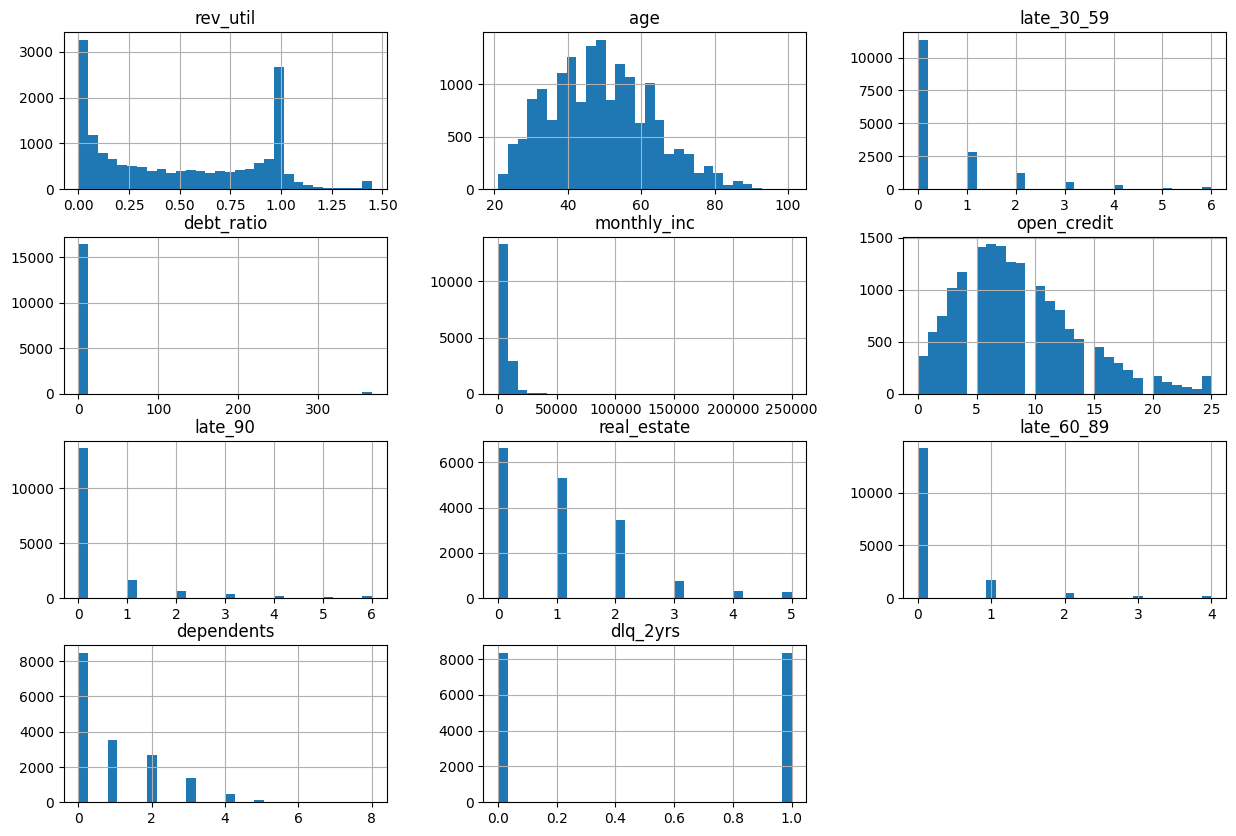

In [9]:
df.hist(figsize=(15,10), bins=30)


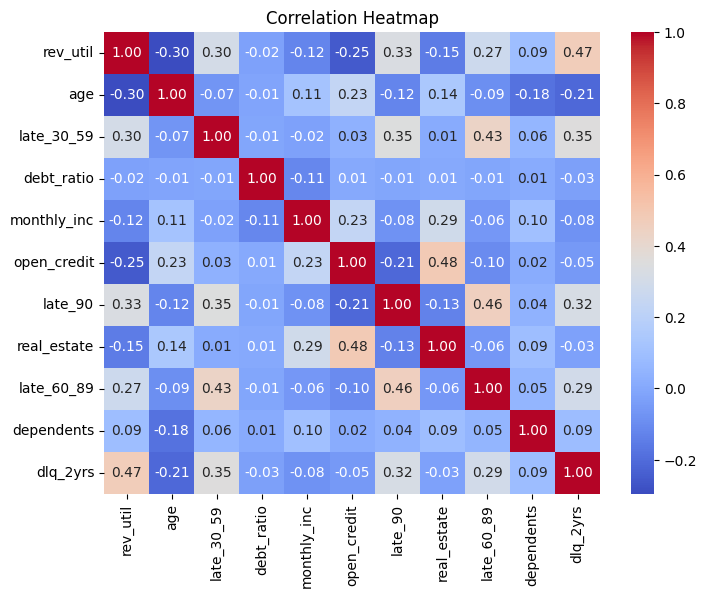

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


ANOVA F-test (specifically f_classif from scikit-learn).

It checks whether the mean values of a feature differ significantly across the classes of your target (dlq_2yrs = 0 or 1).

In [11]:
from sklearn.feature_selection import SelectKBest, f_classif

X = df.drop('dlq_2yrs', axis=1)
y = df['dlq_2yrs']

selector = SelectKBest(score_func=f_classif, k='all')
fit = selector.fit(X, y)

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': fit.scores_
}).sort_values(by='F-Score', ascending=False)

print(feature_scores)


       Feature      F-Score
0     rev_util  4765.989189
2   late_30_59  2379.984466
6      late_90  1915.105853
8   late_60_89  1568.647051
1          age   776.396884
9   dependents   126.115907
4  monthly_inc   113.552819
5  open_credit    47.599412
3   debt_ratio    17.061411
7  real_estate    11.614662


In [12]:
# Features & Target
X = df.drop('dlq_2yrs', axis=1)
y = df['dlq_2yrs']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Logistic Regression (with regularization)
log_reg = LogisticRegression(max_iter=1000, solver='liblinear')

log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred_proba))


Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.76      0.81      0.78      2508
           1       0.79      0.75      0.77      2507

    accuracy                           0.78      5015
   macro avg       0.78      0.78      0.78      5015
weighted avg       0.78      0.78      0.78      5015

AUC: 0.8545867424480991


In [14]:
# Duplicate dataframe
df_reduced = df.copy()

# Remove weak features
df_reduced = df_reduced.drop(['debt_ratio', 'real_estate', 'open_credit'], axis=1)

# Train-test split
X = df_reduced.drop('dlq_2yrs', axis=1)
y = df_reduced['dlq_2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, solver='liblinear')
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

# Evaluation
print("Reduced Feature Logistic Regression Results:")
print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred_proba))


Reduced Feature Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.75      0.81      0.77      2508
           1       0.79      0.73      0.76      2507

    accuracy                           0.77      5015
   macro avg       0.77      0.77      0.77      5015
weighted avg       0.77      0.77      0.77      5015

AUC: 0.8476722911096141


In [15]:
from sklearn.decomposition import PCA

# Features/Target
X = df.drop('dlq_2yrs', axis=1)
y = df['dlq_2yrs']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA (keep 95% variance)
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X.shape)
print("Transformed shape:", X_pca.shape)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.3, random_state=42, stratify=y
)

# Logistic Regression on PCA features
log_reg = LogisticRegression(max_iter=1000, solver='liblinear')
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

print("PCA + Logistic Regression Results:")
print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred_proba))


Original shape: (16714, 10)
Transformed shape: (16714, 9)
PCA + Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.76      0.81      0.78      2508
           1       0.80      0.74      0.77      2507

    accuracy                           0.78      5015
   macro avg       0.78      0.78      0.77      5015
weighted avg       0.78      0.78      0.77      5015

AUC: 0.8533010282532671


In [16]:
# Step 1: Define features (X) and target (y)
X = df.drop("dlq_2yrs", axis=1)   # Features
y = df["dlq_2yrs"]               # Target

# Step 2: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 3: Feature scaling (important for regularization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 4: Logistic Regression with L1 and L2 regularization
from sklearn.linear_model import LogisticRegression

# L1 Regularization (Lasso) - promotes sparsity (some coefficients = 0)
log_reg_l1 = LogisticRegression(penalty='l1', solver='liblinear', random_state=42)
log_reg_l1.fit(X_train_scaled, y_train)

# L2 Regularization (Ridge) - shrinks coefficients but keeps all features
log_reg_l2 = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=1000, random_state=42)
log_reg_l2.fit(X_train_scaled, y_train)

# Step 5: Evaluation
from sklearn.metrics import classification_report, roc_auc_score

# Predictions
y_pred_l1 = log_reg_l1.predict(X_test_scaled)
y_pred_l2 = log_reg_l2.predict(X_test_scaled)

print("L1 Logistic Regression (Lasso) Results:")
print(classification_report(y_test, y_pred_l1))
print("ROC-AUC:", roc_auc_score(y_test, log_reg_l1.predict_proba(X_test_scaled)[:,1]))

print("\nL2 Logistic Regression (Ridge) Results:")
print(classification_report(y_test, y_pred_l2))
print("ROC-AUC:", roc_auc_score(y_test, log_reg_l2.predict_proba(X_test_scaled)[:,1]))



L1 Logistic Regression (Lasso) Results:
              precision    recall  f1-score   support

           0       0.76      0.80      0.78      1672
           1       0.79      0.74      0.77      1671

    accuracy                           0.77      3343
   macro avg       0.77      0.77      0.77      3343
weighted avg       0.77      0.77      0.77      3343

ROC-AUC: 0.8536879472223893

L2 Logistic Regression (Ridge) Results:
              precision    recall  f1-score   support

           0       0.76      0.80      0.78      1672
           1       0.79      0.74      0.76      1671

    accuracy                           0.77      3343
   macro avg       0.77      0.77      0.77      3343
weighted avg       0.77      0.77      0.77      3343

ROC-AUC: 0.85368651553807


In [17]:
from sklearn.linear_model import LogisticRegression

# Step 1: Define Elastic Net Logistic Regression
# solver must be 'saga' to support elasticnet
elastic_net_model = LogisticRegression(
    penalty='elasticnet',
    solver='saga',
    l1_ratio=0.5,          # 50% L1 + 50% L2
    C=1.0,                 # Regularization strength (lower = stronger regularization)
    max_iter=5000,
    random_state=42
)

# Step 2: Fit model
elastic_net_model.fit(X_train_scaled, y_train)

# Step 3: Predictions
y_pred_en = elastic_net_model.predict(X_test_scaled)
y_prob_en = elastic_net_model.predict_proba(X_test_scaled)[:,1]

# Step 4: Evaluation
print("Elastic Net Logistic Regression Results (L1 + L2):")
print(classification_report(y_test, y_pred_en))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_en))

# Step 5: Check coefficients
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": elastic_net_model.coef_[0]
}).sort_values(by="Coefficient", key=abs, ascending=False)

print("\nTop coefficients (Elastic Net):")
print(coef_df.head(10))


Elastic Net Logistic Regression Results (L1 + L2):
              precision    recall  f1-score   support

           0       0.76      0.80      0.78      1672
           1       0.79      0.74      0.77      1671

    accuracy                           0.77      3343
   macro avg       0.77      0.77      0.77      3343
weighted avg       0.77      0.77      0.77      3343

ROC-AUC: 0.8536968952493852

Top coefficients (Elastic Net):
       Feature  Coefficient
6      late_90     1.002337
0     rev_util     0.788764
2   late_30_59     0.673172
8   late_60_89     0.658982
1          age    -0.260029
5  open_credit     0.240953
4  monthly_inc    -0.134556
7  real_estate     0.106171
3   debt_ratio    -0.060651
9   dependents     0.053682


In [18]:
# 1️⃣ Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:,1]

print("Decision Tree Results:")
print(classification_report(y_test, y_pred_dt))
print("AUC:", roc_auc_score(y_test, y_proba_dt))

Decision Tree Results:
              precision    recall  f1-score   support

           0       0.77      0.76      0.77      1672
           1       0.76      0.78      0.77      1671

    accuracy                           0.77      3343
   macro avg       0.77      0.77      0.77      3343
weighted avg       0.77      0.77      0.77      3343

AUC: 0.8412167240772079



Random Forest Results:
              precision    recall  f1-score   support

           0       0.78      0.78      0.78      1672
           1       0.78      0.77      0.78      1671

    accuracy                           0.78      3343
   macro avg       0.78      0.78      0.78      3343
weighted avg       0.78      0.78      0.78      3343

AUC: 0.8598021340686465


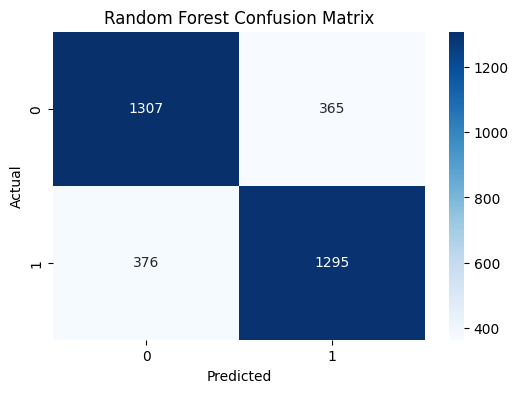

In [19]:
# 2️⃣ Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

print("\nRandom Forest Results:")
print(classification_report(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_proba_rf))

# Confusion Matrix for Random Forest
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [20]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import numpy as np

param_dist = {
    'n_estimators': [200, 300, 500, 800],
    'max_depth': [5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', 0.5],
    'bootstrap': [True, False],
    'class_weight': [None, 'balanced']
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=30,               # number of combinations to try
    scoring='roc_auc',
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best AUC:", random_search.best_score_)


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10, 'class_weight': None, 'bootstrap': True}
Best AUC: 0.8514745913652767


In [21]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split

# Split data
X = df.drop('dlq_2yrs', axis=1)
y = df['dlq_2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Initialize XGBoost model
xgb_model = xgb.XGBClassifier(
    n_estimators=300,        # number of trees
    learning_rate=0.05,      # step size shrinkage
    max_depth=6,             # tree depth
    subsample=0.8,           # row sampling
    colsample_bytree=0.8,    # feature sampling
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'    # avoids warning
)

# Train model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("XGBoost Results:")
print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred_proba))


c:\Users\jitesh\Lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


XGBoost Results:
              precision    recall  f1-score   support

           0       0.77      0.80      0.79      2508
           1       0.80      0.77      0.78      2507

    accuracy                           0.78      5015
   macro avg       0.78      0.78      0.78      5015
weighted avg       0.78      0.78      0.78      5015

AUC: 0.8557062553399126


In [22]:
# pip install gradio


In [23]:
import gradio as gr
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# ✅ Use your already trained model
rf = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42)
rf.fit(X_train, y_train)

# Function to make prediction
def predict_credit_risk(rev_util, age, late_30_59, debt_ratio, monthly_inc,
                        open_credit, late_90, real_estate, late_60_89, dependents):
    
    new_data = pd.DataFrame([{
        "rev_util": rev_util,
        "age": age,
        "late_30_59": late_30_59,
        "debt_ratio": debt_ratio,
        "monthly_inc": monthly_inc,
        "open_credit": open_credit,
        "late_90": late_90,
        "real_estate": real_estate,
        "late_60_89": late_60_89,
        "dependents": dependents
    }])
    
    prediction = rf.predict(new_data)[0]
    probability = rf.predict_proba(new_data)[0, 1]
    
    return {
        "Risk Class": "High Risk (1)" if prediction == 1 else "Low Risk (0)",
        "Probability of Default": f"{probability:.2f}"
    }

# Gradio UI
inputs = [
    gr.Slider(0, 1, 0.5, label="Revolving Utilization Ratio (0-1)"),
    gr.Slider(18, 100, 35, step=1, label="Age"),
    gr.Number(label="Times 30-59 days late"),
    gr.Slider(0, 1, 0.5, label="Debt Ratio (0-1)"),
    gr.Number(label="Monthly Income"),
    gr.Number(label="Open Credit Lines"),
    gr.Number(label="Times 90+ days late"),
    gr.Number(label="Real Estate Loans/Lines"),
    gr.Number(label="Times 60-89 days late"),
    gr.Number(label="Dependents")
]

outputs = gr.JSON(label="Prediction Result")

demo = gr.Interface(fn=predict_credit_risk, inputs=inputs, outputs=outputs, title="📊 Credit Risk Predictor")
demo.launch()


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [24]:
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import classification_report, roc_auc_score
# from sklearn.ensemble import RandomForestClassifier
# from xgboost import XGBClassifier

# # ---------------------------
# # 1. Feature Engineering
# # ---------------------------
# df_fe = df.copy()

# # Total late payments
# df_fe["total_late"] = df_fe["late_30_59"] + df_fe["late_60_89"] + df_fe["late_90"]

# # Flag if borrower was ever late
# df_fe["has_late"] = (df_fe["total_late"] > 0).astype(int)

# # Utilization buckets (binning)
# df_fe["rev_util_bin"] = pd.cut(df_fe["rev_util"],
#                                bins=[-np.inf, 0.3, 0.6, 0.9, np.inf],
#                                labels=["low", "medium", "high", "very_high"])

# # Encode the categorical bin
# df_fe = pd.get_dummies(df_fe, columns=["rev_util_bin"], drop_first=True)

# # Debt-to-income interaction
# df_fe["debt_income_interaction"] = df_fe["debt_ratio"] * df_fe["monthly_inc"]

# # Open credit per income
# df_fe["open_credit_per_income"] = df_fe["open_credit"] / (df_fe["monthly_inc"] + 1)

# # ---------------------------
# # 2. Train/Test Split
# # ---------------------------
# X = df_fe.drop("dlq_2yrs", axis=1)
# y = df_fe["dlq_2yrs"]

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

# # ---------------------------
# # 3. Random Forest
# # ---------------------------
# rf = RandomForestClassifier(
#     n_estimators=300, max_depth=10, class_weight="balanced", random_state=42
# )
# rf.fit(X_train, y_train)

# y_pred_rf = rf.predict(X_test)
# y_proba_rf = rf.predict_proba(X_test)[:, 1]

# print("\nRandom Forest with Feature Engineering")
# print(classification_report(y_test, y_pred_rf))
# print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

# # ---------------------------
# # 4. XGBoost
# # ---------------------------
# xgb = XGBClassifier(
#     n_estimators=300,
#     learning_rate=0.05,
#     max_depth=6,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     use_label_encoder=False,
#     eval_metric="logloss"
# )
# xgb.fit(X_train, y_train)

# y_pred_xgb = xgb.predict(X_test)
# y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

# print("\nXGBoost with Feature Engineering")
# print(classification_report(y_test, y_pred_xgb))
# print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))
